# 02 — Embeddings (and why they win)

BoW used a sparse count vector: one slot per vocab word, mostly zeros, and no
notion that "king" and "queen" are related. A **learned embedding** maps each
word to a small dense vector. Same task, same prediction head — we only swap
the representation, then compare perplexity head-to-head with notebook 01.

In [1]:
import os
import re
import json
from collections import Counter

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(1337)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

with open("data/shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

Rebuild the same word-level tokenizer and dataset as notebook 01 (self-contained).

In [2]:
def tokenize_words(s: str) -> list[str]:
    return re.findall(r"[a-z]+|[^a-z\s]", s.lower())

VOCAB_SIZE = 2000
CONTEXT = 8

counts = Counter(tokenize_words(text))
itos = ["<unk>"] + [w for w, _ in counts.most_common(VOCAB_SIZE - 1)]
stoi = {w: i for i, w in enumerate(itos)}
vocab_size = len(itos)
unk = stoi["<unk>"]

def encode(s): return [stoi.get(w, unk) for w in tokenize_words(s)]

ids_all = encode(text)
split = int(0.9 * len(ids_all))
train_ids, val_ids = ids_all[:split], ids_all[split:]

def make_dataset(ids, context, limit):
    xs, ys = [], []
    step = max(1, (len(ids) - context - 1) // limit)
    for i in range(0, len(ids) - context - 1, step):
        xs.append(ids[i:i + context])
        ys.append(ids[i + context])
    return torch.tensor(xs), torch.tensor(ys)

Xtr, Ytr = make_dataset(train_ids, CONTEXT, 20000)
Xva, Yva = make_dataset(val_ids, CONTEXT, 4000)
Xtr, Ytr, Xva, Yva = Xtr.to(device), Ytr.to(device), Xva.to(device), Yva.to(device)
print("context windows:", tuple(Xtr.shape))

context windows: (21512, 8)


## The mean-embedding model

Look up an embedding for each of the `CONTEXT` words, average them, and project
to next-word logits. Note: we keep it order-blind on purpose (averaging) so the
*only* thing that changes vs BoW is sparse-counts -> dense-learned vectors.

In [3]:
EMB_DIM = 64

class MeanEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):            # x: (B, T) int ids
        e = self.emb(x)              # (B, T, E)
        pooled = e.mean(dim=1)       # (B, E) — order-blind
        return self.fc(pooled)       # (B, vocab)

model = MeanEmbeddingModel(vocab_size, EMB_DIM).to(device)
emb_params = sum(p.numel() for p in model.parameters())
print("Embedding-model params:", emb_params)

Embedding-model params: 258000


## Train (same recipe as BoW)

/var/folders/g8/cmwrqbfj25v5665lrlf7z4b40000gn/T/ipykernel_74619/1539210325.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  losses.append(float(loss))


Embedding val perplexity 261.9


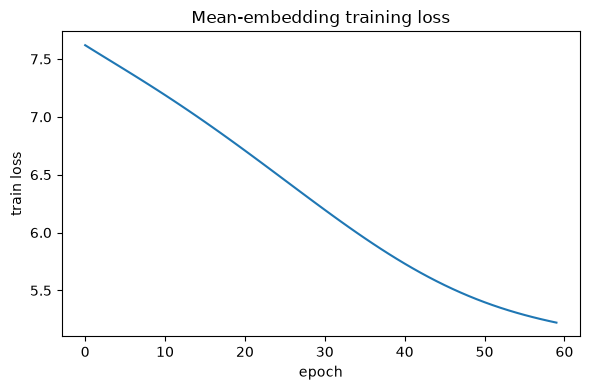

In [4]:
def evaluate(m, X, Y):
    m.eval()
    with torch.no_grad():
        loss = nn.functional.cross_entropy(m(X), Y)
    m.train()
    return float(loss)

opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
losses = []
for epoch in range(60):
    logits = model(Xtr)
    loss = nn.functional.cross_entropy(logits, Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(float(loss))

emb_val_loss = evaluate(model, Xva, Yva)
emb_val_ppl = float(torch.exp(torch.tensor(emb_val_loss)))
print(f"Embedding val perplexity {emb_val_ppl:.1f}")

os.makedirs("assets", exist_ok=True)
plt.figure(figsize=(6, 4))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("train loss")
plt.title("Mean-embedding training loss"); plt.tight_layout()
plt.savefig("assets/02_embedding_loss.png", dpi=120); plt.show()

## Head-to-head with the BoW baseline

In [5]:
with open("assets/phase1_metrics.json") as f:
    bow_metrics = json.load(f)
bow_val_ppl = bow_metrics["bow_val_perplexity"]
bow_params = bow_metrics["bow_params"]

print(f"BoW       : perplexity {bow_val_ppl:7.1f} | params {bow_params:,}")
print(f"Embeddings: perplexity {emb_val_ppl:7.1f} | params {emb_params:,}")
assert emb_val_ppl < bow_val_ppl, "embeddings should achieve lower perplexity than BoW"
assert emb_params < bow_params, "embeddings should use far fewer parameters than BoW"
print("Embeddings win: lower perplexity AND fewer parameters.")

BoW       : perplexity   264.1 | params 4,002,000
Embeddings: perplexity   261.9 | params 258,000
Embeddings win: lower perplexity AND fewer parameters.


## But embeddings are *still* order-blind

Averaging is permutation-invariant, so reordering the context gives the same
prediction — exactly BoW's flaw. Dense vectors fixed *representation*, not
*order*. Order is what **attention** (notebook 03) finally gives us.

In [6]:
a = torch.tensor([encode("the king is dead")[:CONTEXT]], device=device)
b = torch.tensor([list(reversed(encode("the king is dead")[:CONTEXT]))], device=device)
with torch.no_grad():
    pa, pb = model(a), model(b)
assert torch.allclose(pa, pb, atol=1e-5), "mean-pooling is order-blind"
print("Confirmed: reordering the context does not change the prediction.")

Confirmed: reordering the context does not change the prediction.


## Switching to characters for the transformer

From here on the model is character-level: a tiny, fully transparent vocab
(~65 symbols), no `<unk>`, no vocabulary cap. We tensorize the whole corpus
and define the batching helper Phase 2 will reuse.

In [7]:
chars = sorted(set(text))
cstoi = {c: i for i, c in enumerate(chars)}
citos = {i: c for c, i in cstoi.items()}
char_vocab_size = len(chars)
print("char vocab:", char_vocab_size)

cdata = torch.tensor([cstoi[c] for c in text], dtype=torch.long)
cn = int(0.9 * len(cdata))
ctrain, cval = cdata[:cn], cdata[cn:]

BLOCK = 64   # context length in characters
BATCH = 32

def get_batch(split: str):
    d = ctrain if split == "train" else cval
    ix = torch.randint(len(d) - BLOCK - 1, (BATCH,))
    xb = torch.stack([d[i:i + BLOCK] for i in ix])
    yb = torch.stack([d[i + 1:i + 1 + BLOCK] for i in ix])
    return xb.to(device), yb.to(device)

xb, yb = get_batch("train")
assert xb.shape == (BATCH, BLOCK) and yb.shape == (BATCH, BLOCK)
print("char batch:", tuple(xb.shape), "-> targets", tuple(yb.shape))
print("Ready for attention in notebook 03.")

char vocab: 65
char batch: (32, 64) -> targets (32, 64)
Ready for attention in notebook 03.
